Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [ ]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [3]:
# Specify file paths
data_file = "20260121-cytation3-pure-timecourse-gfp-OnePotPURE-Opt2-biotek-cdk.txt"
platemap_file = "20260121-OnePotPURE-Opt2-Platemap.csv"

# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Date,Experiment Name,Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B8,43,B,8,GFP-F-G35,2026-01-21 11:35:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
1,0 days 00:05:00,B8,41,B,8,GFP-F-G35,2026-01-21 11:40:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
2,0 days 00:10:00,B8,41,B,8,GFP-F-G35,2026-01-21 11:45:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
3,0 days 00:15:00,B8,73,B,8,GFP-F-G35,2026-01-21 11:50:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
4,0 days 00:20:00,B8,452,B,8,GFP-F-G35,2026-01-21 11:55:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10


## Plot Raw Curves

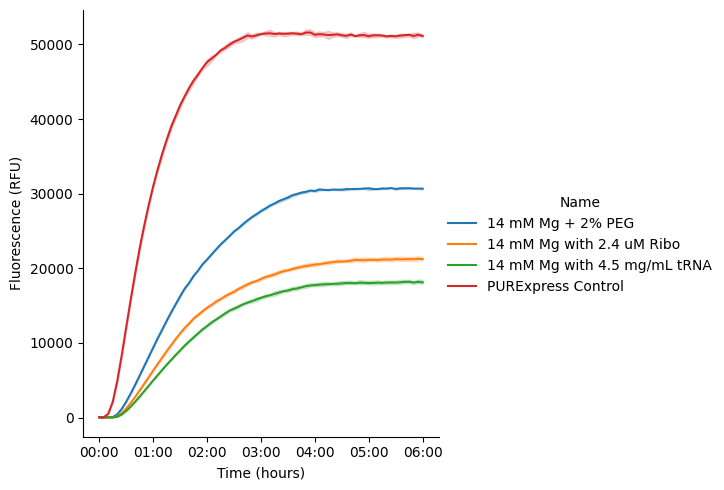

In [4]:
g = pr.plot_curves(data=data)
plt.savefig("g.png")

## Normalize Data

In [13]:
data = pr.normalize_data_to_controls(data, ctrl_name = '10 uM HPTS')

Data Normalized to 10 uM HPTS in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

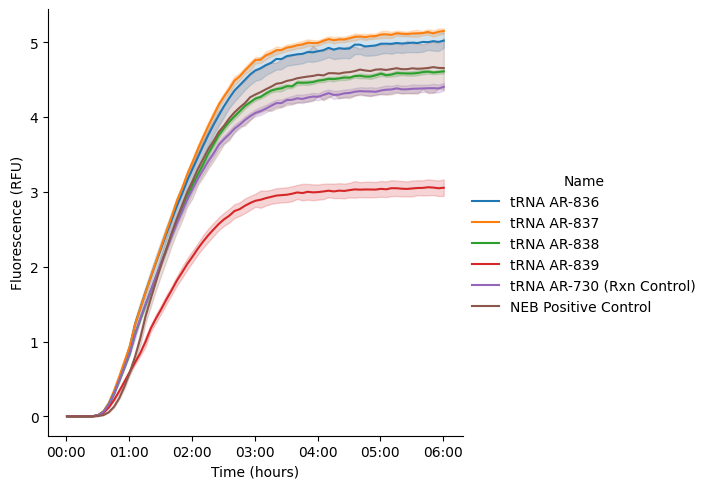

In [14]:
g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [5]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

Calculating Kinetics


Velocity                    \
                                                    Time     Data      Max   
Name                      Well                                               
14 mM Mg + 2% PEG         B8   0 days 01:14:56.516265603 15346.15 13175.34   
                          B10  0 days 01:16:17.314291045 15437.35 13278.68   
                          B12  0 days 01:16:18.947501119 15368.28 13239.69   
14 mM Mg with 2.4 uM Ribo D8   0 days 01:10:58.367100885 10556.23  8944.87   
                          D10  0 days 01:10:26.514135552 10810.44  9110.32   

                                                       Lag           \
                                                      Time     Data   
Name                      Well                                        
14 mM Mg + 2% PEG         B8     0 days 00:05:03.370741350  -276.09   
                          B10    0 days 00:06:32.075638300   -75.48   
                          B12    0 days 00:06:40.161602833   -59.71   
14 mM Mg with 2.4 uM Ribo D8     0 days 00:00:09.850049424  -949.45   
                          D10  -1 days +23:59:14.702875397 -1069.89   

                                            Steady State           \
                                                    Time     Data   
Name                      Well                                      
14 mM Mg + 2% PEG         B8   0 days 02:57:49.746828175 29157.68   
                          B10  0 days 02:58:58.904204109 29330.97   
                          B12  0 days 02:58:51.037543200 29199.74   
14 mM Mg with 2.4 uM Ribo D8   0 days 02:55:13.116704570 20056.85   
                          D10  0 days 02:55:15.557927757 20539.83   

                                                                              Fit  \
                                                                           params   
Name                      Well                                                      
14 mM Mg + 2% PEG         B8    [30692.290658897193, 1.71708803317071, 1.24903...   
                          B10   [30874.701503881137, 1.7203320043304993, 1.271...   
                          B12   [30736.56454114219, 1.7229884888710056, 1.2719...   
14 mM Mg with 2.4 uM Ribo D8    [21112.468852464935, 1.6947089806372584, 1.182...   
                          D10   [21620.8756913301, 1.6854677237474653, 1.17403...   

                                                     
                                R^2  drift good_fit  
Name                      Well                       
14 mM Mg + 2% PEG         B8   1.00 787.58     True  
                          B10  1.00 757.09     True  
                          B12  1.00 760.41     True  
14 mM Mg with 2.4 uM Ribo D8   1.00 639.20     True  
                          D10  1.00 673.57     True

## Visualize Fits on Individual Wells

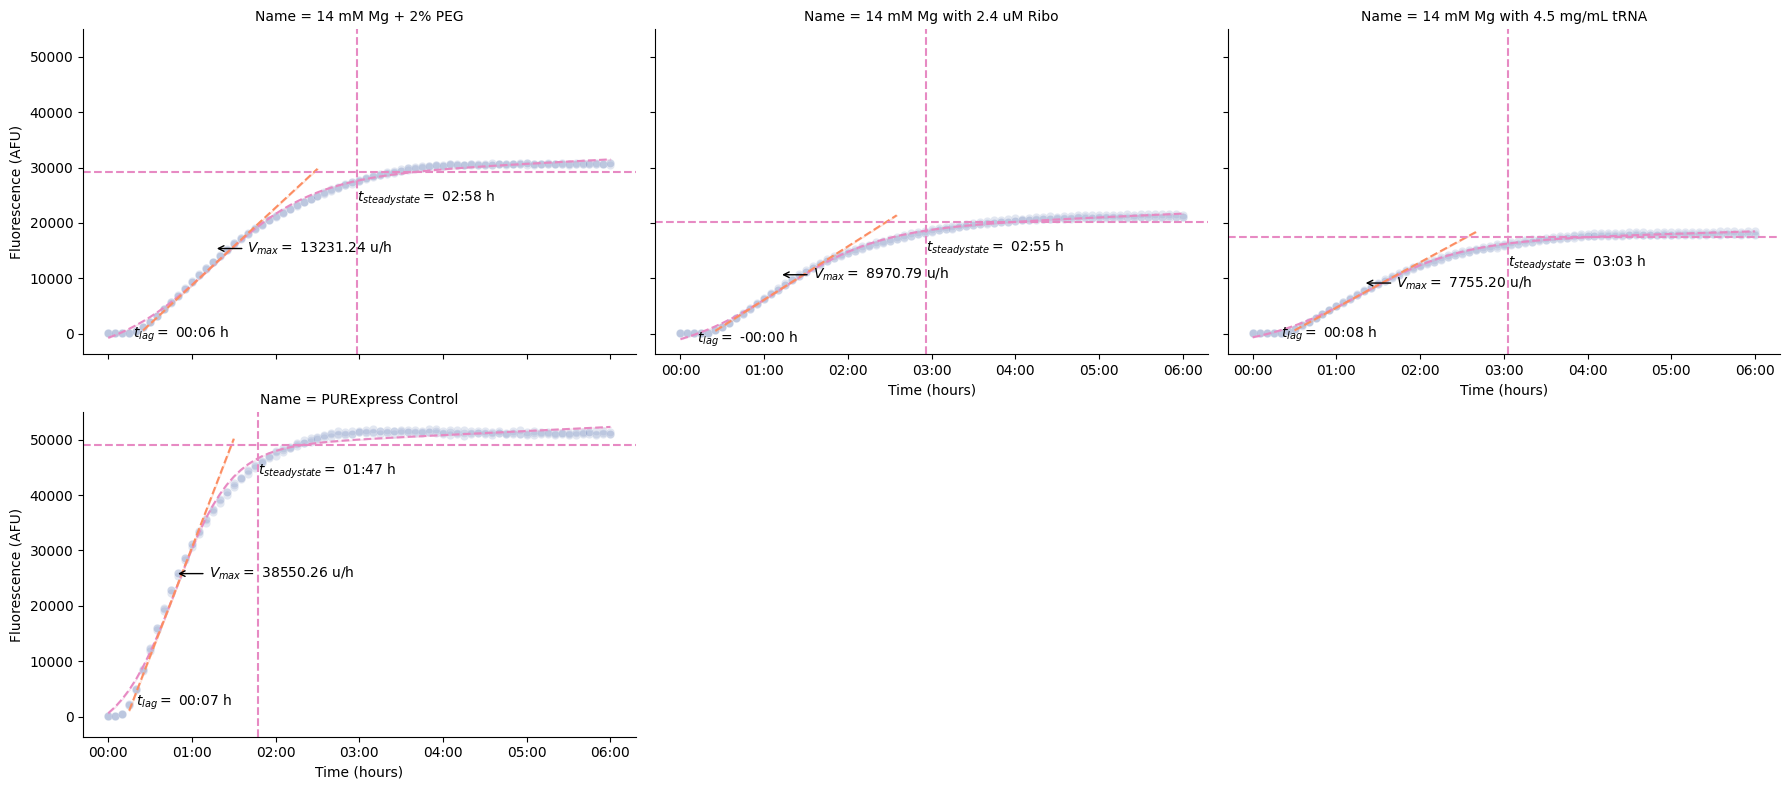

In [6]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

Calculating Kinetics


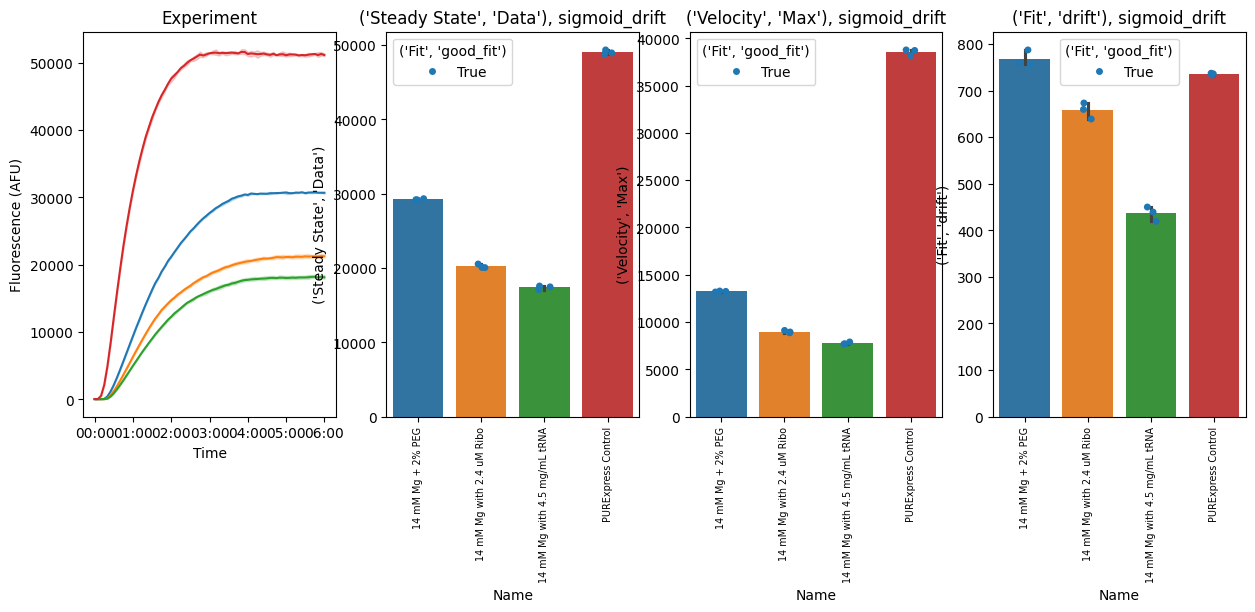

In [7]:
summary_plot = pr.plot_summary(data)
plt.savefig("summary_plot.png")

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants